# 10 minutes to pandas

In [2]:
import numpy as np
import pandas as pd

In [3]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

In [4]:
dates = pd.date_range("20130101", periods=6)
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[us]', freq='D')

In [5]:
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))
df

,A,B,C,D
2013-01-01,0.996463,0.079001,-1.200146,1.457609
2013-01-02,0.561814,-0.295967,0.906421,0.728734
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564
2013-01-04,-1.666615,-1.776855,1.388988,1.263763
2013-01-05,-1.402379,0.274760,0.574237,-1.815439
2013-01-06,0.348980,0.713812,-0.481335,0.883125


Remark: columns = ... seems useful for the variables as in the idea of tidy data

In [ ]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)
df2

A           float64
B    datetime64[us]
C           float32
D             int32
E          category
F               str
dtype: object

Remark: This dictionary of objects method of creating a df seems useful for the melting part in tidy data.

In [15]:
df2.dtypes

A           float64
B    datetime64[us]
C           float32
D             int32
E          category
F               str
dtype: object

In [10]:
df.head()

,A,B,C,D
2013-01-01,0.996463,0.079001,-1.200146,1.457609
2013-01-02,0.561814,-0.295967,0.906421,0.728734
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564
2013-01-04,-1.666615,-1.776855,1.388988,1.263763
2013-01-05,-1.402379,0.274760,0.574237,-1.815439


In [11]:
df.tail(3)

,A,B,C,D
2013-01-04,-1.666615,-1.776855,1.388988,1.263763
2013-01-05,-1.402379,0.274760,0.574237,-1.815439
2013-01-06,0.348980,0.713812,-0.481335,0.883125


In [12]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[us]', freq='D')

In [13]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='str')

In [16]:
df.to_numpy()

array([[ 0.99646329,  0.07900064, -1.2001456 ,  1.45760901],
       [ 0.561814  , -0.29596745,  0.90642111,  0.72873396],
       [ 0.67859104, -1.5241115 , -2.10274628, -0.29256393],
       [-1.66661502, -1.77685477,  1.38898775,  1.26376268],
       [-1.40237863,  0.27476027,  0.57423702, -1.8154395 ],
       [ 0.34898016,  0.71381213, -0.4813353 ,  0.88312464]])

In [18]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.080524,-0.421560,-0.152430,0.370871
std,1.148583,1.009228,1.344232,1.231976
min,-1.666615,-1.776855,-2.102746,-1.815439
25%,-0.964539,-1.217075,-1.020443,-0.037239
50%,0.455397,-0.108483,0.046451,0.805929
75%,0.649397,0.225820,0.823375,1.168603
max,0.996463,0.713812,1.388988,1.457609


In [19]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,0.996463,0.561814,0.678591,-1.666615,-1.402379,0.348980
B,0.079001,-0.295967,-1.524111,-1.776855,0.274760,0.713812
C,-1.200146,0.906421,-2.102746,1.388988,0.574237,-0.481335
D,1.457609,0.728734,-0.292564,1.263763,-1.815439,0.883125


In [20]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,1.457609,-1.200146,0.079001,0.996463
2013-01-02,0.728734,0.906421,-0.295967,0.561814
2013-01-03,-0.292564,-2.102746,-1.524111,0.678591
2013-01-04,1.263763,1.388988,-1.776855,-1.666615
2013-01-05,-1.815439,0.574237,0.274760,-1.402379
2013-01-06,0.883125,-0.481335,0.713812,0.348980


In [22]:
df.sort_values(by="B")

,A,B,C,D
2013-01-04,-1.666615,-1.776855,1.388988,1.263763
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564
2013-01-02,0.561814,-0.295967,0.906421,0.728734
2013-01-01,0.996463,0.079001,-1.200146,1.457609
2013-01-05,-1.402379,0.274760,0.574237,-1.815439
2013-01-06,0.348980,0.713812,-0.481335,0.883125


In [23]:
df["A"]

2013-01-01    0.996463
2013-01-02    0.561814
2013-01-03    0.678591
2013-01-04   -1.666615
2013-01-05   -1.402379
2013-01-06    0.348980
Freq: D, Name: A, dtype: float64

In [24]:
df.A

2013-01-01    0.996463
2013-01-02    0.561814
2013-01-03    0.678591
2013-01-04   -1.666615
2013-01-05   -1.402379
2013-01-06    0.348980
Freq: D, Name: A, dtype: float64

In [25]:
df[["B", "A"]]

,B,A
2013-01-01,0.079001,0.996463
2013-01-02,-0.295967,0.561814
2013-01-03,-1.524111,0.678591
2013-01-04,-1.776855,-1.666615
2013-01-05,0.274760,-1.402379
2013-01-06,0.713812,0.348980


In [27]:
df[0:3]

,A,B,C,D
2013-01-01,0.996463,0.079001,-1.200146,1.457609
2013-01-02,0.561814,-0.295967,0.906421,0.728734
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564


In [28]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,0.561814,-0.295967,0.906421,0.728734
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564
2013-01-04,-1.666615,-1.776855,1.388988,1.263763


In [29]:
df.loc[dates[0]]

A    0.996463
B    0.079001
C   -1.200146
D    1.457609
Name: 2013-01-01 00:00:00, dtype: float64

In [33]:
df.loc[:, ["A", "B"]]

,A,B
2013-01-01,0.996463,0.079001
2013-01-02,0.561814,-0.295967
2013-01-03,0.678591,-1.524111
2013-01-04,-1.666615,-1.776855
2013-01-05,-1.402379,0.274760
2013-01-06,0.348980,0.713812


In [34]:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,0.561814,-0.295967
2013-01-03,0.678591,-1.524111
2013-01-04,-1.666615,-1.776855


In [35]:
df.loc[dates[0], "A"]

np.float64(0.9964632857923565)

In [36]:
df.at[dates[0], "A"]

np.float64(0.9964632857923565)

In [37]:
df[df["A"] > 0]

,A,B,C,D
2013-01-01,0.996463,0.079001,-1.200146,1.457609
2013-01-02,0.561814,-0.295967,0.906421,0.728734
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564
2013-01-06,0.348980,0.713812,-0.481335,0.883125


In [38]:
df[df > 0]

,A,B,C,D
2013-01-01,0.996463,0.079001,NaN,1.457609
2013-01-02,0.561814,NaN,0.906421,0.728734
2013-01-03,0.678591,NaN,NaN,NaN
2013-01-04,NaN,NaN,1.388988,1.263763
2013-01-05,NaN,0.274760,0.574237,NaN
2013-01-06,0.348980,0.713812,NaN,0.883125


In [39]:
df2 = df.copy()
df2["E"] = ["one", "one", "two", "three", "four", "three"]
df2

,A,B,C,D,E
2013-01-01,0.996463,0.079001,-1.200146,1.457609,one
2013-01-02,0.561814,-0.295967,0.906421,0.728734,one
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564,two
2013-01-04,-1.666615,-1.776855,1.388988,1.263763,three
2013-01-05,-1.402379,0.274760,0.574237,-1.815439,four
2013-01-06,0.348980,0.713812,-0.481335,0.883125,three


In [40]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,E
2013-01-03,0.678591,-1.524111,-2.102746,-0.292564,two
2013-01-05,-1.402379,0.274760,0.574237,-1.815439,four


In [41]:
s1 = pd.Series(
   [1, 2, 3, 4, 5, 6],
   index=pd.date_range("20130102", periods=6))
s1


2013-01-02    1
2013-01-03    2
2013-01-04    3
2013-01-05    4
2013-01-06    5
2013-01-07    6
Freq: D, dtype: int64

In [42]:
df["F"] = s1

In [43]:
df.at[dates[0], "A"] = 0

In [47]:
df.iat[0, 1] = 0

In [48]:
df.loc[:, "D"] = np.array([5] * len(df))

In [49]:
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-1.200146,5.0,NaN
2013-01-02,0.561814,-0.295967,0.906421,5.0,1.0
2013-01-03,0.678591,-1.524111,-2.102746,5.0,2.0
2013-01-04,-1.666615,-1.776855,1.388988,5.0,3.0
2013-01-05,-1.402379,0.274760,0.574237,5.0,4.0
2013-01-06,0.348980,0.713812,-0.481335,5.0,5.0


In [50]:
df2 = df.copy()
df2[df2 > 0] = -df2
df2

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-1.200146,-5.0,NaN
2013-01-02,-0.561814,-0.295967,-0.906421,-5.0,-1.0
2013-01-03,-0.678591,-1.524111,-2.102746,-5.0,-2.0
2013-01-04,-1.666615,-1.776855,-1.388988,-5.0,-3.0
2013-01-05,-1.402379,-0.274760,-0.574237,-5.0,-4.0
2013-01-06,-0.348980,-0.713812,-0.481335,-5.0,-5.0


In [51]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])
df1.loc[dates[0] : dates[1], "E"] = 1
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-1.200146,5.0,NaN,1.0
2013-01-02,0.561814,-0.295967,0.906421,5.0,1.0,1.0
2013-01-03,0.678591,-1.524111,-2.102746,5.0,2.0,NaN
2013-01-04,-1.666615,-1.776855,1.388988,5.0,3.0,NaN


In [52]:
df1.dropna(how="any")

,A,B,C,D,F,E
2013-01-02,0.561814,-0.295967,0.906421,5.0,1.0,1.0


In [53]:
df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-1.200146,5.0,5.0,1.0
2013-01-02,0.561814,-0.295967,0.906421,5.0,1.0,1.0
2013-01-03,0.678591,-1.524111,-2.102746,5.0,2.0,5.0
2013-01-04,-1.666615,-1.776855,1.388988,5.0,3.0,5.0


In [54]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


In [55]:
df.mean()

A   -0.246601
B   -0.434727
C   -0.152430
D    5.000000
F    3.000000
dtype: float64

In [56]:
df.mean(axis=1)

2013-01-01    0.949964
2013-01-02    1.434454
2013-01-03    0.810347
2013-01-04    1.189104
2013-01-05    1.689324
2013-01-06    2.116291
Freq: D, dtype: float64

In [57]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
s

2013-01-01    NaN
2013-01-02    NaN
2013-01-03    1.0
2013-01-04    3.0
2013-01-05    5.0
2013-01-06    NaN
Freq: D, dtype: float64

In [58]:
df.sub(s, axis="index")

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-0.321409,-2.524111,-3.102746,4.0,1.0
2013-01-04,-4.666615,-4.776855,-1.611012,2.0,0.0
2013-01-05,-6.402379,-4.725240,-4.425763,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


In [59]:
df.agg(lambda x: np.mean(x) * 5.6)

A    -1.380968
B    -2.434471
C    -0.853609
D    28.000000
F    16.800000
dtype: float64

In [60]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-121.454735,506.0,NaN
2013-01-02,56.855577,-29.951906,91.729816,506.0,101.2
2013-01-03,68.673414,-154.240083,-212.797923,506.0,202.4
2013-01-04,-168.661440,-179.817703,140.565561,506.0,303.6
2013-01-05,-141.920718,27.805739,58.112787,506.0,404.8
2013-01-06,35.316792,72.237788,-48.711133,506.0,506.0


... is equivalent to ...

In [61]:
def my_function(x):
    return np.mean(x) * 5.6

df.agg(my_function)

A    -1.380968
B    -2.434471
C    -0.853609
D    28.000000
F    16.800000
dtype: float64

In [62]:
s = pd.Series(np.random.randint(0, 7, size=10))
s

0    1
1    1
2    5
3    4
4    6
5    4
6    4
7    6
8    2
9    3
dtype: int32

In [63]:
s.value_counts()

4    3
1    2
6    2
5    1
2    1
3    1
Name: count, dtype: int64

In [64]:
df = pd.DataFrame(np.random.randn(10, 4))
df

,0,1,2,3
0,-0.314915,-0.832620,-1.302814,1.080755
1,0.577354,1.666507,-1.320559,0.495172
2,0.241859,0.218614,0.769301,0.755614
3,-1.135756,-0.285077,0.912010,1.071006
4,0.690039,0.218925,-0.208459,0.309910
5,0.351718,0.513585,1.327930,-2.804312
6,0.644401,-0.507506,0.361565,-2.321277
7,0.061204,2.357117,-1.374858,0.691394
8,0.572804,-1.337034,0.040292,-0.478806
9,-0.811985,-0.065216,-1.263721,-0.334822


In [65]:
pieces = [df[:3], df[3:7], df[7:]]
pd.concat(pieces)

,0,1,2,3
0,-0.314915,-0.832620,-1.302814,1.080755
1,0.577354,1.666507,-1.320559,0.495172
2,0.241859,0.218614,0.769301,0.755614
3,-1.135756,-0.285077,0.912010,1.071006
4,0.690039,0.218925,-0.208459,0.309910
5,0.351718,0.513585,1.327930,-2.804312
6,0.644401,-0.507506,0.361565,-2.321277
7,0.061204,2.357117,-1.374858,0.691394
8,0.572804,-1.337034,0.040292,-0.478806
9,-0.811985,-0.065216,-1.263721,-0.334822


In [66]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
left

,key,lval
0,foo,1
1,foo,2


In [67]:
right

,key,rval
0,foo,4
1,foo,5


In [69]:
pd.merge(left, right, on = "key")

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


In [70]:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})
left

,key,lval
0,foo,1
1,bar,2


In [71]:
right

,key,rval
0,foo,4
1,bar,5


In [72]:
pd.merge(left, right, on = "key")

,key,lval,rval
0,foo,1,4
1,bar,2,5


In [73]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
df

,A,B,C,D
0,foo,one,-1.383355,-0.621682
1,bar,one,-1.452713,-0.316719
2,foo,two,0.422632,-0.976123
3,bar,three,0.827926,0.512660
4,foo,two,0.408348,1.081722
5,bar,two,-0.820803,0.379006
6,foo,one,-0.559538,0.005590
7,foo,three,-1.718565,-0.557812


In [74]:
df.groupby("A")[["C", "D"]].sum()

,C,D
A,,
bar,-1.445589,0.574947
foo,-2.830478,-1.068306


In [75]:
df.groupby(["A", "B"]).sum()

C         D
A   B                        
bar one   -1.452713 -0.316719
    three  0.827926  0.512660
    two   -0.820803  0.379006
foo one   -1.942894 -0.616092
    three -1.718565 -0.557812
    two    0.830980  0.105598

In [77]:
arrays = [
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])
df2 = df[:4]
df2

A         B
first second                    
bar   one     1.515339  0.348750
      two    -1.063502  0.796924
baz   one     0.506959 -0.006906
      two    -2.271429  0.073187

Stacking seems opposite to the idea of tidy data. 

In [78]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
df

,A,B,C,D,E
0,one,A,foo,-0.347932,1.207571
1,one,B,foo,1.051698,-0.524999
2,two,C,foo,-1.710680,-0.480754
3,three,A,bar,0.693236,-1.218147
4,one,B,bar,-1.612916,-1.120687
5,one,C,bar,-0.060189,2.424937
6,two,A,foo,-1.273682,-0.263791
7,three,B,foo,-1.131169,-0.664265
8,one,C,foo,0.827994,0.098721
9,one,A,bar,1.109345,0.198930


In [79]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

C             bar       foo
A     B                    
one   A  1.109345 -0.347932
      B -1.612916  1.051698
      C -0.060189  0.827994
three A  0.693236       NaN
      B       NaN -1.131169
      C -0.702003       NaN
two   A       NaN -1.273682
      B  1.348837       NaN
      C       NaN -1.710680

In [80]:
rng = pd.date_range("3/6/2012 00:00", periods=5, freq="D")
ts = pd.Series(np.random.randn(len(rng)), rng)
ts

2012-03-06    1.493240
2012-03-07   -0.490156
2012-03-08   -1.544152
2012-03-09   -1.299510
2012-03-10    0.139673
Freq: D, dtype: float64

In [82]:
ts_utc = ts.tz_localize("UTC")
ts_utc

2012-03-06 00:00:00+00:00    1.493240
2012-03-07 00:00:00+00:00   -0.490156
2012-03-08 00:00:00+00:00   -1.544152
2012-03-09 00:00:00+00:00   -1.299510
2012-03-10 00:00:00+00:00    0.139673
Freq: D, dtype: float64

In [84]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, str): ['a', 'b', 'e']

In [89]:
import matplotlib.pyplot as plt
plt.close("all")

<Axes: >

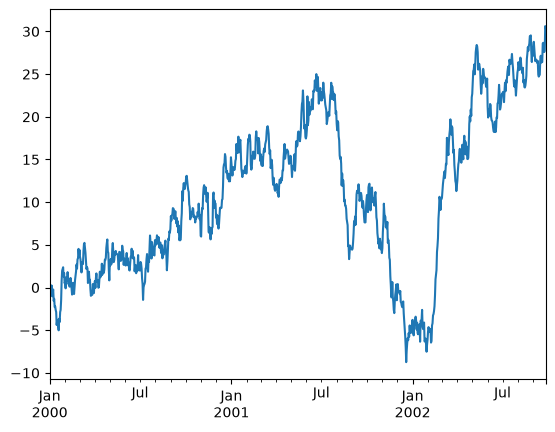

In [91]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))
ts = ts.cumsum()
ts.plot()

<Figure size 640x480 with 0 Axes>

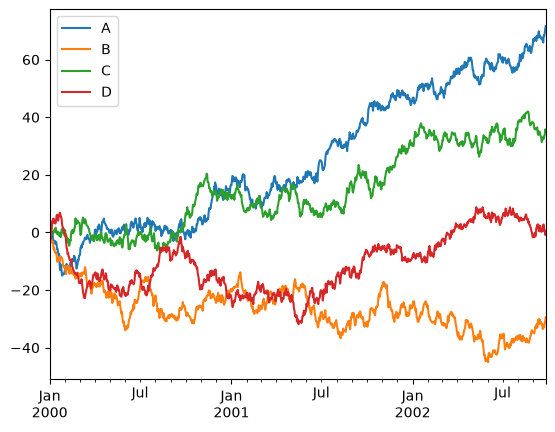

In [92]:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)
df = df.cumsum()
plt.figure();
df.plot();
plt.legend(loc='best');

.pivot() for reshaping data, e.g. no2_subset.pivot(columns="location", values="value")